# 🫀 ECG Arrhythmia Inference + Frequency Equalizer
### Loads pretrained weights from Drive — zero training

## Full pipeline
```
 .wav / .dat file
       │
       ▼
 [1] Load & resample to 360 Hz
       │
       ▼
 [2] GQRS R-peak detector  →  beat positions  (WHERE = localisation)
       │
       ▼
 [3] Pretrained ResNet     →  class per beat  (WHAT  = classification)
       │
       ▼
 [4] FFT per class group   →  dominant freq band per arrhythmia
       │
       ▼
 [5] Equalizer sliders     →  gain × FFT mask → IFFT → output .wav
```

## 📦 Cell 1 — Install & Imports

In [2]:
!pip install -q wfdb scipy matplotlib seaborn ipywidgets

import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.fft    import fft, ifft, fftfreq
from scipy.io     import wavfile
from scipy.signal import resample_poly
import wfdb
import wfdb.processing as wfdb_proc
import torch, torch.nn as nn, torch.nn.functional as F
import ipywidgets as widgets
from IPython.display import display, Audio
from google.colab import drive

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':110, 'axes.grid':True, 'grid.alpha':0.3})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas

In [88]:
!pip install -q wfdb scipy matplotlib seaborn ipywidgets plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# ── Global constants ───────────────────────────────────────────────────────
FS          = 360
BEAT_LEN    = 187
BEAT_BEFORE = 90
BEAT_AFTER  = BEAT_LEN - BEAT_BEFORE
N_CLASSES   = 5
CLASS_NAMES = ['Normal (N)', 'SVEB (S)', 'PVC (V)', 'Fusion (F)', 'Unknown (Q)']
CLASS_SYMS  = ['N', 'S', 'V', 'F', 'Q']
CLASS_COLORS= ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

WEIGHTS_PATH  = '/content/drive/MyDrive/ECG_Model/ecg_resnet_mitbih.pt'
SETTINGS_PATH = '/content/drive/MyDrive/ECG_Model/ecg_eq_settings.json'

print(f'Device : {DEVICE}')
print(f'Weights: {WEIGHTS_PATH}')

Device : cuda
Weights: /content/drive/MyDrive/ECG_Model/ecg_resnet_mitbih.pt


## 🏗️ Cell 2 — Define Architecture & Load Pretrained Weights

In [4]:
# ── Architecture — must match setup notebook exactly ──────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=False):
        super().__init__()
        stride     = 2 if downsample else 1
        self.conv1 = nn.Conv1d(in_ch, out_ch, 5, stride=stride, padding=2, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 5, padding=2, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.skip  = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if (in_ch != out_ch or downsample) else nn.Identity()

    def forward(self, x):
        return F.relu(
            self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))) + self.skip(x)
        )

class ECGResNet(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3, bias=False),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        self.layer1 = ResBlock(32,  64)
        self.layer2 = ResBlock(64,  128, downsample=True)
        self.layer3 = ResBlock(128, 256, downsample=True)
        self.pool   = nn.AdaptiveAvgPool1d(1)
        self.drop   = nn.Dropout(0.3)
        self.fc     = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(self.drop(self.pool(x).squeeze(-1)))


# ── Load pretrained weights from Drive ────────────────────────────────────
drive.mount('/content/drive')

model = ECGResNet().to(DEVICE)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()   # inference only — disables dropout, no gradients

print('✅ Pretrained model loaded from Drive')
print(f'   Parameters: {sum(p.numel() for p in model.parameters()):,}')
print('   Ready for inference on any ECG file.')

Mounted at /content/drive
✅ Pretrained model loaded from Drive
   Parameters: 692,389
   Ready for inference on any ECG file.


## 🔌 Cell 3 — File Loaders
Both `.wav` and `.dat/.hea` are supported. Output is always the same: **360 Hz, z-score normalised**.

In [5]:
def normalise(sig: np.ndarray) -> np.ndarray:
    """Z-score normalise a 1-D signal."""
    return (sig - sig.mean()) / (sig.std() + 1e-8)


def resample_to_360(sig: np.ndarray, src_fs: int) -> np.ndarray:
    """Polyphase resample from src_fs → 360 Hz."""
    if src_fs == FS:
        return sig
    from math import gcd
    g = gcd(FS, src_fs)
    return resample_poly(sig, FS // g, src_fs // g).astype(np.float32)


def load_wav(path: str) -> tuple[np.ndarray, int]:
    """Load .wav file → float32 signal, sampling rate."""
    fs, data = wavfile.read(path)
    # Convert any integer PCM format to float32 in [-1, 1]
    if data.dtype.kind == 'i':
        data = data.astype(np.float32) / np.iinfo(data.dtype).max
    data = data.astype(np.float32)
    if data.ndim == 2:      # stereo → use channel 0
        data = data[:, 0]
    return data, int(fs)


def load_wfdb(path: str, channel: int = 0) -> tuple[np.ndarray, int]:
    """Load WFDB .dat/.hea record. Pass path without extension."""
    base   = path.replace('.hea','').replace('.dat','')
    rec    = wfdb.rdrecord(base)
    return rec.p_signal[:, channel].astype(np.float32), int(rec.fs)


def load_ecg_file(filepath: str, channel: int = 0) -> tuple[np.ndarray, int]:
    """
    Universal ECG loader — auto-detects format from extension.
    Always returns (signal_360hz_normalised, 360).
    """
    ext = os.path.splitext(filepath)[1].lower()
    sig, src_fs = load_wav(filepath) if ext == '.wav' else load_wfdb(filepath, channel)
    sig = resample_to_360(sig, src_fs)
    sig = normalise(sig)
    return sig, FS


def save_as_wav(signal: np.ndarray, fs: int, out_path: str) -> None:
    """Save float32 signal to 16-bit PCM .wav file."""
    pcm = (signal / (np.abs(signal).max() + 1e-8) * 32767).astype(np.int16)
    wavfile.write(out_path, fs, pcm)
    print(f'💾 Saved → {out_path}')


print('✅ File loaders ready')

✅ File loaders ready


## 💓 Cell 4 — R-Peak Detection & Beat Segmentation
This gives us **WHERE** each heartbeat is in time.

In [6]:
def detect_rpeaks(signal: np.ndarray, fs: int = FS) -> np.ndarray:
    """GQRS R-peak detector. Returns sample indices of each heartbeat."""
    return wfdb_proc.gqrs_detect(sig=signal, fs=fs)


def segment_beats(signal: np.ndarray,
                  r_peaks: np.ndarray
                  ) -> tuple[np.ndarray, np.ndarray]:
    """
    Cut a 187-sample window around each R-peak.

    Returns
    -------
    beats       : (M, 187) float32 — per-beat normalised
    valid_peaks : (M,)     int     — only peaks with complete windows
    """
    beats, valid = [], []
    for rp in r_peaks:
        lo, hi = rp - BEAT_BEFORE, rp + BEAT_AFTER
        if lo < 0 or hi > len(signal):
            continue
        beats.append(normalise(signal[lo:hi].copy()))
        valid.append(rp)
    return np.array(beats, dtype=np.float32), np.array(valid, dtype=int)


print('✅ Beat segmentation ready')

✅ Beat segmentation ready


## 🤖 Cell 5 — AI Classification
This gives us **WHAT** arrhythmia each beat is.

In [7]:
def classify_beats(beats: np.ndarray,
                   batch_size: int = 512
                   ) -> tuple[np.ndarray, np.ndarray]:
    """
    Run pretrained ResNet on beat segments.

    Returns
    -------
    labels : (M,)   int   — predicted class index per beat
    probs  : (M, 5) float — softmax confidence per class
    """
    xt        = torch.tensor(beats[:, np.newaxis, :])   # (M, 1, 187)
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(xt), batch_size):
            logits = model(xt[i : i+batch_size].to(DEVICE))
            all_probs.append(F.softmax(logits, dim=1).cpu())
    probs  = torch.cat(all_probs).numpy()   # (M, 5)
    labels = probs.argmax(axis=1)           # (M,)
    return labels, probs


print('✅ Classifier ready')

✅ Classifier ready


## 🎵 Cell 6 — Dominant Frequency Detection (per arrhythmia class)
This gives us **WHICH frequencies** characterise each arrhythmia type.

**How it works:**
```
Collect all beats of class V (PVC)
        │
        ▼
FFT each beat  →  |FFT|  (magnitude spectrum)
        │
        ▼
Average across all PVC beats  →  avg power spectrum
        │
        ▼
Find peak bin  →  take band [peak-window, peak+window]
        │
        ▼
That band is the PVC frequency fingerprint
```

In [8]:
def find_dominant_bands(beats: np.ndarray,
                         labels: np.ndarray,
                         fs: int = FS,
                         half_win: int = 10
                         ) -> dict:
    """
    For each arrhythmia class, find the dominant frequency band.

    Steps per class:
      1. Collect all beats of that class
      2. Compute average magnitude spectrum via FFT
      3. Smooth and find peak frequency bin
      4. Return band = [peak - half_win bins, peak + half_win bins]

    Returns
    -------
    bands : {class_id: (f_low_hz, f_high_hz, f_peak_hz)}
    """
    freqs = fftfreq(BEAT_LEN, d=1/fs)[:BEAT_LEN // 2]  # positive freqs only
    bands = {}

    for cls in range(N_CLASSES):
        cls_beats = beats[labels == cls]
        if len(cls_beats) == 0:
            bands[cls] = (0.0, 0.0, 0.0)   # class not present in this signal
            continue

        # Step 1: FFT every beat, take magnitude, average across beats
        avg_mag  = np.abs(fft(cls_beats, axis=1))[:, :BEAT_LEN//2].mean(axis=0)

        # Step 2: Smooth with moving average to find broad peak, not just a spike
        smooth   = np.convolve(avg_mag, np.ones(half_win) / half_win, mode='same')

        # Step 3: Find peak bin and define band around it
        peak_bin = int(np.argmax(smooth))
        lo_bin   = max(0, peak_bin - half_win)
        hi_bin   = min(len(freqs) - 1, peak_bin + half_win)

        bands[cls] = (float(freqs[lo_bin]),
                      float(freqs[hi_bin]),
                      float(freqs[peak_bin]))
    return bands


print('✅ Frequency band detector ready')

✅ Frequency band detector ready


## 🎚️ Cell 7 — FFT Equalizer
**Separates arrhythmia components and lets you change them.**

```
signal  →  FFT  →  complex spectrum
                         │
              multiply each bin by gain mask
              ┌──────────────────────────┐
              │  Normal band  × 1.0      │  unchanged
              │  PVC band     × 0.0      │  suppressed
              │  SVEB band    × 1.5      │  amplified
              └──────────────────────────┘
                         │
                        IFFT
                         │
              equalised signal
```

In [81]:
from scipy.fft import fft, ifft, fftfreq

def apply_equalizer(signal: np.ndarray,
                    gains: dict,
                    bands: dict,
                    noise_gain: float = 1.0,
                    fs: int = FS
                    ) -> np.ndarray:

    N     = len(signal)
    freqs = np.abs(fftfreq(N, d=1/fs))
    spec  = fft(signal)

    mask    = np.full(N, noise_gain, dtype=np.float64)
    covered = np.zeros(N, dtype=bool)

    windows = {}
    for cls in range(N_CLASSES):
        f_lo, f_hi, f_peak = bands[cls]
        if f_lo == f_hi == 0.0:
            continue
        sigma  = (f_hi - f_lo) / 2.0 if f_hi > f_lo else 1.0
        window = np.exp(-0.5 * ((freqs - f_peak) / sigma) ** 2)
        window[(freqs < f_lo) | (freqs > f_hi)] = 0.0
        w_max = window.max()
        if w_max > 0:
            window /= w_max
        windows[cls] = window
        covered |= window > 0.01

    mask[~covered] = noise_gain
    mask[covered]  = 1.0

    for cls, window in windows.items():
        gain   = gains.get(cls, 1.0)
        factor = (1.0 - window) + window * gain
        mask[covered] *= factor[covered]

    return np.real(ifft(spec * mask)).astype(np.float32)

## 🔬 Cell 8 — Main Analysis Function
**One function that runs the full pipeline on any file.**

In [82]:
def analyse_ecg(filepath: str, channel: int = 0) -> dict:
    """
    Full pipeline: load → detect → classify → find frequencies.
    Accepts .wav or WFDB (.dat/.hea) files.

    Returns
    -------
    result dict:
      'signal'       (N,)     raw normalised signal at 360 Hz
      'fs'           int      always 360
      'r_peaks'      (M,)     R-peak sample positions
      'beats'        (M,187)  segmented beat windows
      'beat_labels'  (M,)     predicted class per beat    ← CLASSIFICATION
      'beat_probs'   (M,5)    confidence scores
      'beat_times'   (M,2)    [[t_start, t_end], ...]     ← LOCALISATION
      'bands'        dict     {cls:(f_lo,f_hi,f_peak)}    ← DOMINANT FREQS
      'counts'       dict     {cls: n_beats}
    """
    print(f'\n── Analysing: {os.path.basename(filepath)} ───────────────────')

    # Step 1: Load file
    print('  [1/4] Loading file...')
    sig, fs = load_ecg_file(filepath, channel)
    print(f'        {len(sig)} samples  |  {len(sig)/fs:.1f} s  |  {fs} Hz')

    # Step 2: Detect R-peaks  → WHERE each beat is
    print('  [2/4] Detecting R-peaks (GQRS)...')
    r_peaks          = detect_rpeaks(sig, fs)
    beats, valid_rp  = segment_beats(sig, r_peaks)
    print(f'        {len(beats)} valid beats found')

    # Step 3: Classify each beat  → WHAT arrhythmia
    print('  [3/4] Classifying beats (pretrained ResNet)...')
    labels, probs = classify_beats(beats)

    # Step 4: Find dominant frequency per class  → WHICH frequencies
    print('  [4/4] Computing dominant frequency bands...')
    bands = find_dominant_bands(beats, labels, fs)

    # Beat time positions  (start_sec, end_sec) per beat
    beat_times = np.column_stack([
        (valid_rp - BEAT_BEFORE) / fs,
        (valid_rp + BEAT_AFTER)  / fs
    ])
    counts = {c: int((labels == c).sum()) for c in range(N_CLASSES)}

    # ── Print summary ─────────────────────────────────────────────
    print('\n  ── Results ──────────────────────────────────────────')
    for c in range(N_CLASSES):
        n   = counts[c]
        pct = n / len(beats) * 100 if len(beats) else 0
        f_lo, f_hi, f_pk = bands[c]
        bar = '█' * min(int(pct/2), 25)
        print(f'  [{CLASS_SYMS[c]}] {CLASS_NAMES[c]:15s}  '
              f'{n:5d} beats ({pct:5.1f}%)  '
              f'peak={f_pk:5.1f} Hz  band=[{f_lo:.1f},{f_hi:.1f}]  {bar}')

    return dict(signal=sig, fs=fs, r_peaks=valid_rp,
                beats=beats, beat_labels=labels, beat_probs=probs,
                beat_times=beat_times, bands=bands, counts=counts)


print('✅ Analysis pipeline ready')

✅ Analysis pipeline ready


## 📊 Cell 9 — Visualisation Functions

In [89]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_classified_ecg(result: dict, n_seconds: float = 20.0) -> None:
    sig, fs = result['signal'], result['fs']
    n       = min(int(n_seconds * fs), len(sig))
    t       = np.arange(n) / fs

    fig = go.Figure()

    # ECG signal
    fig.add_trace(go.Scatter(
        x=t, y=sig[:n],
        mode='lines',
        line=dict(color='#2c3e50', width=0.8),
        name='ECG'
    ))

    # Colour-coded beat spans + hover labels
    for rp, lb, (t_lo, t_hi) in zip(result['r_peaks'],
                                      result['beat_labels'],
                                      result['beat_times']):
        if t_lo > n_seconds: break
        fig.add_vrect(
            x0=t_lo, x1=min(t_hi, n_seconds),
            fillcolor=CLASS_COLORS[lb], opacity=0.20,
            layer='below', line_width=0,
            annotation_text=CLASS_SYMS[lb],
            annotation_position='top left',
            annotation=dict(font_size=9, font_color=CLASS_COLORS[lb])
        )

    fig.update_layout(
        title=f'AI Beat Classification — first {n/fs:.1f}s',
        xaxis_title='Time (s)',
        yaxis_title='Amplitude',
        height=350,
        legend=dict(orientation='h'),
        template='plotly_white'
    )

    # Legend entries
    for i in range(N_CLASSES):
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=10, color=CLASS_COLORS[i]),
            name=f'{CLASS_SYMS[i]}: {CLASS_NAMES[i]}'
        ))

    fig.show()


def plot_frequency_fingerprints(result: dict) -> None:
    beats, labels, bands = result['beats'], result['beat_labels'], result['bands']
    freqs   = fftfreq(BEAT_LEN, d=1/FS)[:BEAT_LEN//2]
    present = [c for c in range(N_CLASSES) if result['counts'][c] > 0]

    fig = make_subplots(
        rows=1, cols=len(present),
        subplot_titles=[CLASS_NAMES[c] for c in present]
    )

    for col, cls in enumerate(present, start=1):
        avg_mag          = np.abs(fft(beats[labels==cls], axis=1))[:, :BEAT_LEN//2].mean(axis=0)
        f_lo, f_hi, f_pk = bands[cls]

        # Power spectrum line
        fig.add_trace(go.Scatter(
            x=freqs, y=avg_mag,
            mode='lines',
            line=dict(color=CLASS_COLORS[cls], width=1.5),
            name=CLASS_NAMES[cls],
            showlegend=(col == 1)
        ), row=1, col=col)

        # Dominant band shading
        fig.add_vrect(
            x0=f_lo, x1=f_hi,
            fillcolor=CLASS_COLORS[cls], opacity=0.25,
            layer='below', line_width=0,
            row=1, col=col
        )

        # Peak line
        fig.add_vline(
            x=f_pk,
            line=dict(color=CLASS_COLORS[cls], width=1.5, dash='dash'),
            row=1, col=col,
            annotation_text=f'{f_pk:.1f} Hz',
            annotation_position='top right'
        )

    fig.update_layout(
        title='Dominant Frequency Fingerprint per Arrhythmia Class',
        height=350,
        template='plotly_white'
    )
    fig.update_xaxes(title_text='Frequency (Hz)')
    fig.update_yaxes(title_text='Avg |FFT|', col=1)
    fig.show()


def plot_confidence_timeline(result: dict, n_seconds: float = 30.0) -> None:
    times = result['beat_times'][:, 0]
    probs = result['beat_probs']
    mask  = times < n_seconds

    fig = go.Figure()
    for cls in range(N_CLASSES):
        fig.add_trace(go.Bar(
            x=times[mask],
            y=probs[mask, cls],
            name=CLASS_NAMES[cls],
            marker_color=CLASS_COLORS[cls],
            opacity=0.85
        ))

    fig.update_layout(
        barmode='stack',
        title='Per-Beat Classification Confidence Over Time',
        xaxis_title='Time (s)',
        yaxis_title='Confidence',
        yaxis=dict(range=[0, 1]),
        height=300,
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    fig.show()


def plot_equalizer_output(original: np.ndarray,
                           equalised: np.ndarray,
                           gains: dict,
                           bands: dict,
                           fs: int = FS,
                           n_sec: float = 10.0) -> None:

    n = min(int(n_sec * fs), len(original))
    t = np.arange(n) / fs

    def power_spectrum(s):
        N = len(s)
        return fftfreq(N, 1/fs)[:N//2], np.abs(fft(s))[:N//2]

    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=[
            'Time Domain',
            'Power Spectrum (log scale)',
            'Residual = Original − Equalised'
        ],
        vertical_spacing=0.1
    )

    # Panel 1: time domain
    fig.add_trace(go.Scatter(
        x=t, y=original[:n],
        mode='lines', line=dict(color='steelblue', width=0.8),
        name='Original'
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=t, y=equalised[:n],
        mode='lines', line=dict(color='tomato', width=0.8),
        name='Equalised', opacity=0.85
    ), row=1, col=1)

    # Panel 2: power spectrum
    fr_o, ps_o = power_spectrum(original)
    fr_e, ps_e = power_spectrum(equalised)
    fig.add_trace(go.Scatter(
        x=fr_o, y=np.log10(ps_o + 1e-10),
        mode='lines', line=dict(color='steelblue', width=0.9),
        name='Original (log)', showlegend=False
    ), row=2, col=1)
    fig.add_trace(go.Scatter(
        x=fr_e, y=np.log10(ps_e + 1e-10),
        mode='lines', line=dict(color='tomato', width=0.9),
        name='Equalised (log)', showlegend=False, opacity=0.85
    ), row=2, col=1)

    # Highlight modified bands
    for cls, (f_lo, f_hi, _) in bands.items():
        g = gains.get(cls, 1.0)
        if g != 1.0 and f_lo != f_hi:
            fig.add_vrect(
                x0=f_lo, x1=f_hi,
                fillcolor=CLASS_COLORS[cls], opacity=0.15,
                layer='below', line_width=0,
                annotation_text=f'{CLASS_SYMS[cls]} x{g:.1f}',
                annotation_position='top left',
                row=2, col=1
            )

    # Panel 3: residual
    fig.add_trace(go.Scatter(
        x=t, y=(original - equalised)[:n],
        mode='lines', line=dict(color='purple', width=0.8),
        name='Residual', showlegend=False
    ), row=3, col=1)

    fig.update_layout(
        title='ECG Frequency Equalizer Output',
        height=750,
        template='plotly_white',
        legend=dict(orientation='h')
    )
    fig.update_xaxes(title_text='Time (s)',      row=1, col=1)
    fig.update_xaxes(title_text='Frequency (Hz)',row=2, col=1)
    fig.update_xaxes(title_text='Time (s)',      row=3, col=1)
    fig.update_yaxes(title_text='Amplitude',     row=1, col=1)
    fig.update_yaxes(title_text='log|FFT|',      row=2, col=1)
    fig.update_yaxes(title_text='Δ Amplitude',   row=3, col=1)

    fig.show()


print('✅ Plotly visualisation functions ready')

✅ Plotly visualisation functions ready


## 📁 Cell 10 — Upload & Analyse Your ECG File
Upload a `.wav` file OR both `.dat` + `.hea` files together.

In [84]:
from google.colab import files as colab_files

UPLOAD_DIR = '/content/uploads'
os.makedirs(UPLOAD_DIR, exist_ok=True)

print('Upload your ECG file:')
print('  • .wav  →  upload the .wav file')
print('  • WFDB  →  upload BOTH .dat AND .hea files together')
uploaded = colab_files.upload()

# Save uploaded files
for fname, data in uploaded.items():
    with open(f'{UPLOAD_DIR}/{fname}', 'wb') as f:
        f.write(data)
    print(f'  Saved: {fname}  ({len(data)//1024} KB)')

# Auto-detect which file to use as entry point
fnames   = list(uploaded.keys())
wav_files = [f for f in fnames if f.endswith('.wav')]
dat_files = [f for f in fnames if f.endswith('.dat')]

if wav_files:
    ecg_path = f'{UPLOAD_DIR}/{wav_files[0]}'
    print(f'\n→ Detected WAV file: {wav_files[0]}')
elif dat_files:
    ecg_path = f'{UPLOAD_DIR}/{dat_files[0].replace(".dat","")}'
    print(f'\n→ Detected WFDB record: {dat_files[0]}')
else:
    raise ValueError('No .wav or .dat file found. Please re-upload.')

# ── Run full analysis ──────────────────────────────────────────────────────
result = analyse_ecg(ecg_path)

Upload your ECG file:
  • .wav  →  upload the .wav file
  • WFDB  →  upload BOTH .dat AND .hea files together


Saving ecg_sveb.wav to ecg_sveb (5).wav
  Saved: ecg_sveb (5).wav  (468 KB)

→ Detected WAV file: ecg_sveb (5).wav

── Analysing: ecg_sveb (5).wav ───────────────────
  [1/4] Loading file...
        10800 samples  |  30.0 s  |  360 Hz
  [2/4] Detecting R-peaks (GQRS)...
        61 valid beats found
  [3/4] Classifying beats (pretrained ResNet)...
  [4/4] Computing dominant frequency bands...

  ── Results ──────────────────────────────────────────
  [N] Normal (N)          32 beats ( 52.5%)  peak= 11.6 Hz  band=[0.0,30.8]  █████████████████████████
  [S] SVEB (S)            19 beats ( 31.1%)  peak= 11.6 Hz  band=[0.0,30.8]  ███████████████
  [V] PVC (V)              4 beats (  6.6%)  peak= 11.6 Hz  band=[0.0,30.8]  ███
  [F] Fusion (F)           6 beats (  9.8%)  peak= 11.6 Hz  band=[0.0,30.8]  ████
  [Q] Unknown (Q)          0 beats (  0.0%)  peak=  0.0 Hz  band=[0.0,0.0]  


## 📊 Cell 11 — Visualise Results

In [90]:
# Plot 1: ECG with beat-level arrhythmia labels
plot_classified_ecg(result, n_seconds=20)

In [91]:
# Plot 2: Frequency fingerprint of each detected arrhythmia class
plot_frequency_fingerprints(result)

In [92]:
# Plot 3: Per-beat confidence timeline
plot_confidence_timeline(result, n_seconds=40)

## 🎛️ Cell 12 — Interactive Equalizer
Move the sliders to suppress or amplify each arrhythmia component.
- **0.0** = completely suppress that arrhythmia's frequency band
- **1.0** = leave unchanged
- **2.0** = amplify that arrhythmia's frequency band

The output plot and audio update automatically on every slider change.

In [97]:
from google.colab import output
output.enable_custom_widget_manager()

In [98]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

sig   = result['signal']
bands = result['bands']

# ── Sliders ────────────────────────────────────────────────────────────────
sliders = [
    widgets.FloatSlider(
        value=1.0, min=0.0, max=2.0, step=0.05,
        description=f'{CLASS_SYMS[i]} — {CLASS_NAMES[i]}',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='540px')
    )
    for i in range(N_CLASSES)
]

noise_slider = widgets.FloatSlider(
    value=1.0, min=0.0, max=2.0, step=0.05,
    description='🔇 Residual Noise',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='540px')
)

# ── Build a persistent FigureWidget (updates in-place, no flicker) ─────────
def build_eq_figure(original, equalised, gains, bands, fs=FS, n_sec=10.0):
    n = min(int(n_sec * fs), len(original))
    t = np.arange(n) / fs

    def pspec(s):
        N = len(s)
        return fftfreq(N, 1/fs)[:N//2], np.abs(fft(s))[:N//2]

    fr_o, ps_o = pspec(original)
    fr_e, ps_e = pspec(equalised)

    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=['Time Domain', 'Power Spectrum (log)', 'Residual'],
        vertical_spacing=0.1
    )
    fig.add_trace(go.Scatter(x=t, y=original[:n],  line=dict(color='steelblue', width=0.8), name='Original'),  row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=equalised[:n], line=dict(color='tomato',    width=0.8), name='Equalised'), row=1, col=1)
    fig.add_trace(go.Scatter(x=fr_o, y=np.log10(ps_o + 1e-10), line=dict(color='steelblue', width=0.9), name='Original (log)',  showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=fr_e, y=np.log10(ps_e + 1e-10), line=dict(color='tomato',    width=0.9), name='Equalised (log)', showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=(original - equalised)[:n], line=dict(color='purple', width=0.8), name='Residual', showlegend=False), row=3, col=1)

    fig.update_layout(height=700, template='plotly_white',
                      title='ECG Frequency Equalizer Output',
                      legend=dict(orientation='h'))
    fig.update_xaxes(title_text='Time (s)',       row=1, col=1)
    fig.update_xaxes(title_text='Frequency (Hz)', row=2, col=1)
    fig.update_xaxes(title_text='Time (s)',       row=3, col=1)
    fig.update_yaxes(title_text='Amplitude',      row=1, col=1)
    fig.update_yaxes(title_text='log|FFT|',       row=2, col=1)
    fig.update_yaxes(title_text='Δ Amplitude',    row=3, col=1)

    return go.FigureWidget(fig)   # ← FigureWidget renders inside VBox


# Initial render
eq_init  = apply_equalizer(sig, {i:1.0 for i in range(N_CLASSES)}, bands, noise_gain=1.0)
fig_widget = build_eq_figure(sig, eq_init, {i:1.0 for i in range(N_CLASSES)}, bands)

out_audio = widgets.Output()

# ── Update function ────────────────────────────────────────────────────────
def on_slider_change(_):
    gains      = {i: s.value for i, s in enumerate(sliders)}
    noise_gain = noise_slider.value
    eq         = apply_equalizer(sig, gains, bands, noise_gain=noise_gain)

    n   = min(int(10.0 * FS), len(sig))
    t   = np.arange(n) / FS

    def pspec(s):
        N = len(s)
        return fftfreq(N, 1/FS)[:N//2], np.abs(fft(s))[:N//2]

    fr_e, ps_e = pspec(eq)

    # Update traces in-place — no full redraw, no flicker
    with fig_widget.batch_update():
        fig_widget.data[1].y = eq[:n]                        # equalised time domain
        fig_widget.data[3].y = np.log10(ps_e + 1e-10)       # equalised spectrum
        fig_widget.data[4].y = (sig - eq)[:n]               # residual

    with out_audio:
        out_audio.clear_output(wait=True)
        eq_8k = resample_poly(eq, 8000, FS).astype(np.float32)
        display(Audio(eq_8k, rate=8000, autoplay=False))


for s in sliders:
    s.observe(on_slider_change, names='value')
noise_slider.observe(on_slider_change, names='value')

# ── Layout ─────────────────────────────────────────────────────────────────
display(widgets.VBox([
    widgets.HTML(
        '<h3>🎚️ ECG Arrhythmia Equalizer</h3>'
        '<p><b>0</b> = suppress &nbsp;│&nbsp; '
        '<b>1</b> = unchanged &nbsp;│&nbsp; '
        '<b>2</b> = amplify</p>'
    ),
    widgets.HTML('<b>── Arrhythmia Bands ──</b>'),
    *sliders,
    widgets.HTML('<hr><b>── Residual Noise ──</b>'),
    noise_slider,
    widgets.HTML('<hr><b>▶ Equalised signal:</b>'),
    out_audio,
    fig_widget    # ← directly in VBox, no Output() wrapper needed
]))

on_slider_change(None)

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

## 💾 Cell 13 — Save Equalised Signal as .wav

In [39]:
DRIVE_DIR = '/content/drive/MyDrive/ECG_Model'

In [42]:
# Apply current slider gains and save to Drive + download
current_gains = {i: sliders[i].value for i in range(N_CLASSES)}
eq_signal     = apply_equalizer(sig, current_gains, bands)

out_wav = '/content/ecg_equalised.wav'
save_as_wav(eq_signal, FS, out_wav)

# Also save to Drive
drive_out = f'{DRIVE_DIR}/ecg_equalised.wav'
save_as_wav(eq_signal, FS, drive_out)

print('\nGains applied:')
for cls, g in current_gains.items():
    action = 'SUPPRESS' if g < 1 else ('AMPLIFY' if g > 1 else 'unchanged')
    f_lo, f_hi, f_pk = bands[cls]
    print(f'  [{CLASS_SYMS[cls]}] {CLASS_NAMES[cls]:15s}  gain={g:.2f}  ({action})  '
          f'band=[{f_lo:.1f}–{f_hi:.1f} Hz]')

💾 Saved → /content/ecg_equalised.wav
💾 Saved → /content/drive/MyDrive/ECG_Model/ecg_equalised.wav

Gains applied:
  [N] Normal (N)       gain=1.00  (unchanged)  band=[0.0–30.8 Hz]
  [S] SVEB (S)         gain=1.75  (AMPLIFY)  band=[0.0–30.8 Hz]
  [V] PVC (V)          gain=1.75  (AMPLIFY)  band=[0.0–30.8 Hz]
  [F] Fusion (F)       gain=1.00  (unchanged)  band=[0.0–0.0 Hz]
  [Q] Unknown (Q)      gain=1.00  (unchanged)  band=[0.0–0.0 Hz]


## ⚙️ Cell 14 — Save/Load Equalizer Settings JSON

In [87]:
def save_settings(bands: dict, gains: dict) -> None:
    """Save current equalizer state to JSON on Drive."""
    cfg = {
        'mode'     : 'ECG Abnormalities',
        'fs'       : FS,
        'n_classes': N_CLASSES,
        'sliders'  : [
            {
                'id'        : c,
                'label'     : CLASS_NAMES[c],
                'symbol'    : CLASS_SYMS[c],
                'gain'      : gains.get(c, 1.0),
                'freq_bands': [{'f_low' : bands[c][0],
                                'f_high': bands[c][1],
                                'f_peak': bands[c][2]}]
            }
            for c in range(N_CLASSES)
        ]
    }
    with open(SETTINGS_PATH, 'w') as f:
        json.dump(cfg, f, indent=2)
    print(f'Settings saved → {SETTINGS_PATH}')
    print(json.dumps(cfg, indent=2))


def load_settings() -> tuple[dict, dict]:
    """Load equalizer state from JSON. Returns (bands, gains)."""
    with open(SETTINGS_PATH) as f:
        cfg = json.load(f)
    bands = {s['id']: (s['freq_bands'][0]['f_low'],
                        s['freq_bands'][0]['f_high'],
                        s['freq_bands'][0]['f_peak'])
             for s in cfg['sliders']}
    gains = {s['id']: s['gain'] for s in cfg['sliders']}
    print(f'Settings loaded ← {SETTINGS_PATH}')
    return bands, gains


# Save current state
save_settings(bands, current_gains)

Settings saved → /content/drive/MyDrive/ECG_Model/ecg_eq_settings.json
{
  "mode": "ECG Abnormalities",
  "fs": 360,
  "n_classes": 5,
  "sliders": [
    {
      "id": 0,
      "label": "Normal (N)",
      "symbol": "N",
      "gain": 1.0,
      "freq_bands": [
        {
          "f_low": 0.0,
          "f_high": 30.802139037433154,
          "f_peak": 11.550802139037433
        }
      ]
    },
    {
      "id": 1,
      "label": "SVEB (S)",
      "symbol": "S",
      "gain": 1.75,
      "freq_bands": [
        {
          "f_low": 0.0,
          "f_high": 30.802139037433154,
          "f_peak": 11.550802139037433
        }
      ]
    },
    {
      "id": 2,
      "label": "PVC (V)",
      "symbol": "V",
      "gain": 1.75,
      "freq_bands": [
        {
          "f_low": 0.0,
          "f_high": 30.802139037433154,
          "f_peak": 11.550802139037433
        }
      ]
    },
    {
      "id": 3,
      "label": "Fusion (F)",
      "symbol": "F",
      "gain": 1.0,
      "freq_b

## ⚔️ Cell 15 — AI vs Equalizer Comparison
Quantitative comparison for your project report.

  AI MODEL  vs  FREQUENCY EQUALIZER — Comparison

[AI] Mean confidence per detected class:
  [N] Normal (N)       confidence=78.3%  (32 beats)
  [S] SVEB (S)         confidence=69.7%  (19 beats)
  [V] PVC (V)          confidence=70.3%  (4 beats)
  [F] Fusion (F)       confidence=67.3%  (6 beats)
  [Q] Unknown (Q)      confidence=0.0%  (0 beats)

[EQ] SNR change when suppressing each arrhythmia band:
  [N] Normal (N)       SNR=1.56 dB  (band=[0.0,30.8] Hz,  peak=11.6 Hz)
  [S] SVEB (S)         SNR=1.56 dB  (band=[0.0,30.8] Hz,  peak=11.6 Hz)
  [V] PVC (V)          SNR=1.56 dB  (band=[0.0,30.8] Hz,  peak=11.6 Hz)
  [F] Fusion (F)       SNR=1.56 dB  (band=[0.0,30.8] Hz,  peak=11.6 Hz)
  [Q] Unknown (Q)      SNR=119.91 dB  (band=[0.0,0.0] Hz,  peak=0.0 Hz)


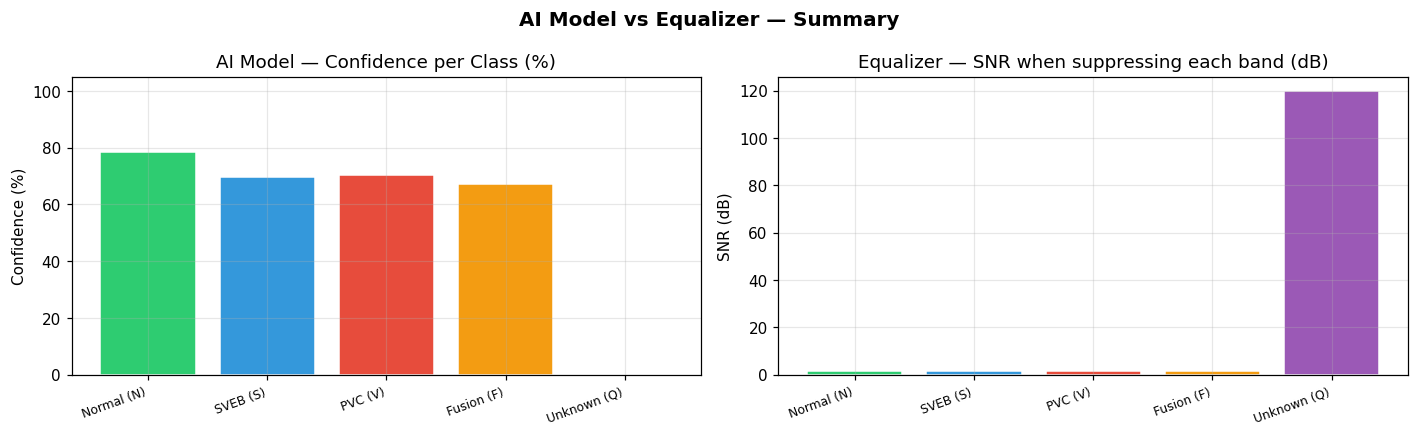


── Interpretation ──────────────────────────────────────
  AI    → identifies WHAT arrhythmia is present & WHERE in time
  EQ    → identifies WHICH frequencies and lets you MODIFY them
  Both  → AI detects the arrhythmia → EQ suppresses its freq band


In [99]:
def snr_db(original: np.ndarray, processed: np.ndarray) -> float:
    """Signal-to-Noise Ratio in dB. Higher = less signal modification."""
    noise = original - processed
    return 10 * np.log10(np.mean(original**2) / (np.mean(noise**2) + 1e-12))


def compare_ai_vs_equalizer(result: dict) -> None:
    sig    = result['signal']
    labels = result['beat_labels']
    probs  = result['beat_probs']
    bands  = result['bands']

    print('=' * 62)
    print('  AI MODEL  vs  FREQUENCY EQUALIZER — Comparison')
    print('=' * 62)

    # AI: mean confidence per detected class
    print('\n[AI] Mean confidence per detected class:')
    ai_conf = {}
    for cls in range(N_CLASSES):
        mask = labels == cls
        conf = probs[mask, cls].mean() * 100 if mask.sum() > 0 else 0.0
        ai_conf[cls] = conf
        print(f'  [{CLASS_SYMS[cls]}] {CLASS_NAMES[cls]:15s}  '
              f'confidence={conf:.1f}%  ({mask.sum()} beats)')

    # Equalizer: SNR when suppressing each class band
    print('\n[EQ] SNR change when suppressing each arrhythmia band:')
    eq_snr = {}
    for cls in range(N_CLASSES):
        gains = {c: 1.0 for c in range(N_CLASSES)}
        gains[cls] = 0.0
        eq  = apply_equalizer(sig, gains, bands)
        snr = snr_db(sig, eq)
        eq_snr[cls] = snr
        f_lo, f_hi, f_pk = bands[cls]
        print(f'  [{CLASS_SYMS[cls]}] {CLASS_NAMES[cls]:15s}  '
              f'SNR={snr:.2f} dB  (band=[{f_lo:.1f},{f_hi:.1f}] Hz,  peak={f_pk:.1f} Hz)')

    # Summary bar chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.bar(CLASS_NAMES, [ai_conf[c] for c in range(N_CLASSES)],
            color=CLASS_COLORS, edgecolor='white')
    ax1.set(title='AI Model — Confidence per Class (%)',
            ylabel='Confidence (%)', ylim=(0, 105))
    plt.setp(ax1.get_xticklabels(), rotation=20, ha='right', fontsize=8)

    ax2.bar(CLASS_NAMES, [eq_snr[c] for c in range(N_CLASSES)],
            color=CLASS_COLORS, edgecolor='white')
    ax2.set(title='Equalizer — SNR when suppressing each band (dB)',
            ylabel='SNR (dB)')
    plt.setp(ax2.get_xticklabels(), rotation=20, ha='right', fontsize=8)

    fig.suptitle('AI Model vs Equalizer — Summary',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print('\n── Interpretation ──────────────────────────────────────')
    print('  AI    → identifies WHAT arrhythmia is present & WHERE in time')
    print('  EQ    → identifies WHICH frequencies and lets you MODIFY them')
    print('  Both  → AI detects the arrhythmia → EQ suppresses its freq band')


compare_ai_vs_equalizer(result)